In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# Parámetros de la población y la imagen
POPULATION_SIZE = 50
IMAGE_HEIGHT = 120
IMAGE_WIDTH = 180
COLOR_CHANNELS = 3 # Para RGB

# Generar la población inicial de matrices aleatorias
# Cada individuo es una matriz de (IMAGE_HEIGHT, IMAGE_WIDTH, COLOR_CHANNELS)
# con valores enteros de 0 a 255.
population = [np.random.randint(0, 256, size=(IMAGE_HEIGHT, IMAGE_WIDTH, COLOR_CHANNELS), dtype=np.uint8) for _ in range(POPULATION_SIZE)]

print(f"Población generada: {len(population)} individuos.")
print(f"Forma de un individuo (imagen): {population[0].shape}")

Población generada: 50 individuos.
Forma de un individuo (imagen): (120, 180, 3)


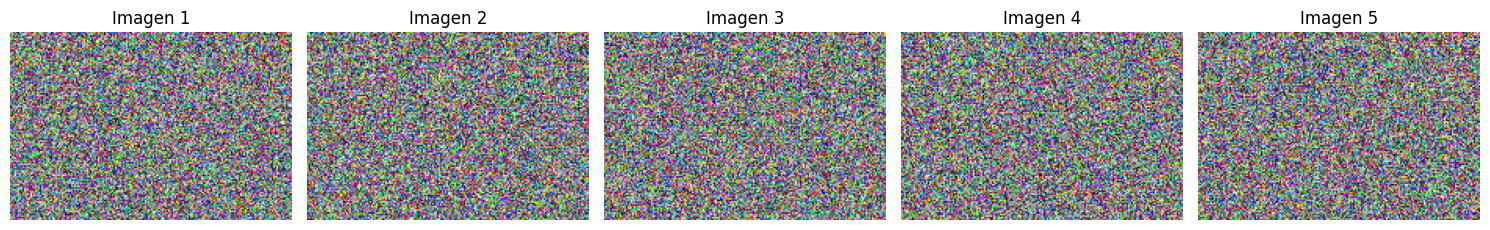

In [28]:
# Mostrar algunas de las imágenes generadas aleatoriamente
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    axes[i].imshow(population[i])
    axes[i].set_title(f'Imagen {i+1}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

Imagen objetivo creada.


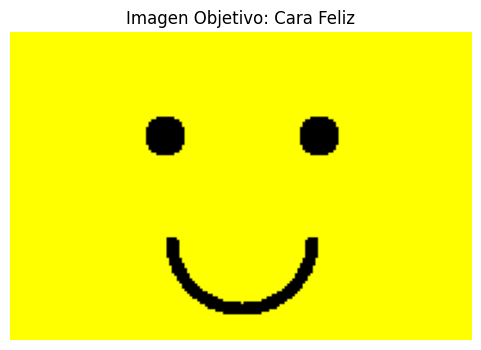

In [29]:
# Crear la imagen objetivo: una cara feliz simple
target_image = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH, COLOR_CHANNELS), dtype=np.uint8)

# Fondo amarillo
target_image[:, :] = [255, 255, 0] # Amarillo

# Ojos negros (dos círculos)
eyes_radius = 8
left_eye_center = (IMAGE_HEIGHT // 3, IMAGE_WIDTH // 3)
right_eye_center = (IMAGE_HEIGHT // 3, 2 * IMAGE_WIDTH // 3)

for i in range(IMAGE_HEIGHT):
    for j in range(IMAGE_WIDTH):
        # Ojo izquierdo
        if (i - left_eye_center[0])**2 + (j - left_eye_center[1])**2 < eyes_radius**2:
            target_image[i, j] = [0, 0, 0] # Negro
        # Ojo derecho
        if (i - right_eye_center[0])**2 + (j - right_eye_center[1])**2 < eyes_radius**2:
            target_image[i, j] = [0, 0, 0] # Negro

# Sonrisa negra (un arco)
smile_center = (2 * IMAGE_HEIGHT // 3, IMAGE_WIDTH // 2)
smile_radius = 30
smile_thickness = 5

for i in range(IMAGE_HEIGHT):
    for j in range(IMAGE_WIDTH):
        dist_from_center = np.sqrt((i - smile_center[0])**2 + (j - smile_center[1])**2)
        # Asegurarse de que sea la parte inferior del círculo para la sonrisa
        if (smile_center[0] <= i) and (smile_radius - smile_thickness < dist_from_center < smile_radius):
            target_image[i, j] = [0, 0, 0] # Negro

print("Imagen objetivo creada.")

# Mostrar la imagen objetivo
plt.figure(figsize=(6, 4))
plt.imshow(target_image)
plt.title('Imagen Objetivo: Cara Feliz')
plt.axis('off')
plt.show()

In [30]:
def fitness_function(individual):
    # Calcular el Error Cuadrático Medio (MSE) entre el individuo y la imagen objetivo
    # Cuanto menor sea el MSE, más apto es el individuo.
    mse = np.mean((individual - target_image)**2)
    return mse

print("Función de aptitud definida.")

# Ejemplo de uso de la función de aptitud (opcional)
# fitness_score_example = fitness_function(population[0])
# print(f"Puntaje de aptitud para el primer individuo: {fitness_score_example}")

Función de aptitud definida.


In [31]:
def select_parents(population, fitness_scores, num_parents):
    # La selección por torneo es una buena opción aquí.
    # Seleccionamos k individuos al azar y elegimos el mejor de ellos.
    # Para simplificar, aquí simplemente seleccionaremos los mejores basados en fitness.
    # Queremos minimizar el MSE, por lo que los puntajes más bajos son mejores.
    sorted_indices = np.argsort(fitness_scores) # Ordenar de menor a mayor MSE
    parents = [population[i] for i in sorted_indices[:num_parents]]
    return parents

def crossover(parent1, parent2):
    # Cruce de un solo punto en el eje de la altura
    crossover_point = np.random.randint(1, IMAGE_HEIGHT - 1)
    child = np.copy(parent1)
    child[crossover_point:] = parent2[crossover_point:]
    return child

def mutate(individual, mutation_rate=0.01):
    # Mutación: cambiar aleatoriamente algunos píxeles
    mutation_mask = np.random.rand(IMAGE_HEIGHT, IMAGE_WIDTH, COLOR_CHANNELS) < mutation_rate
    random_values = np.random.randint(0, 256, size=(IMAGE_HEIGHT, IMAGE_WIDTH, COLOR_CHANNELS), dtype=np.uint8)
    individual[mutation_mask] = random_values[mutation_mask]
    return individual

print("Operadores de selección, cruce y mutación definidos.")

Operadores de selección, cruce y mutación definidos.


In [32]:
# Parámetros del Algoritmo Genético
NUM_GENERATIONS = 4000 # Número de generaciones a ejecutar
NUM_PARENTS = 10      # Número de padres a seleccionar para la reproducción
MUTATION_RATE = 0.02  # Tasa de mutación

best_fitness_per_generation = []
best_individual_per_generation = []

print("Iniciando el algoritmo genético...")

for generation in range(NUM_GENERATIONS):
    # 1. Calcular la aptitud de cada individuo
    fitness_scores = [fitness_function(ind) for ind in population]
    current_best_fitness = np.min(fitness_scores)
    best_fitness_per_generation.append(current_best_fitness)
    current_best_individual_index = np.argmin(fitness_scores)
    best_individual_per_generation.append(population[current_best_individual_index])

    if generation % 20 == 0:
        print(f"Generación {generation}: Mejor Aptitud (MSE) = {current_best_fitness:.2f}")

    # 2. Selección de padres
    parents = select_parents(population, fitness_scores, NUM_PARENTS)

    # 3. Creación de la nueva generación (descendencia)
    next_population = []

    # Mantener a los mejores padres (elitismo)
    next_population.extend(parents)

    # Rellenar el resto de la población con descendencia
    while len(next_population) < POPULATION_SIZE:
        # Elegir dos padres al azar de los seleccionados
        parent1 = parents[np.random.randint(0, NUM_PARENTS)]
        parent2 = parents[np.random.randint(0, NUM_PARENTS)]

        # Realizar cruce
        child = crossover(parent1, parent2)

        # Realizar mutación
        child = mutate(child, MUTATION_RATE)
        next_population.append(child)

    population = next_population

print("Algoritmo genético completado.")
print(f"Mejor aptitud final (MSE): {best_fitness_per_generation[-1]:.2f}")

Iniciando el algoritmo genético...
Generación 0: Mejor Aptitud (MSE) = 104.90
Generación 20: Mejor Aptitud (MSE) = 103.01
Generación 40: Mejor Aptitud (MSE) = 101.80
Generación 60: Mejor Aptitud (MSE) = 101.12
Generación 80: Mejor Aptitud (MSE) = 100.52
Generación 100: Mejor Aptitud (MSE) = 100.01
Generación 120: Mejor Aptitud (MSE) = 99.57
Generación 140: Mejor Aptitud (MSE) = 99.26
Generación 160: Mejor Aptitud (MSE) = 98.93
Generación 180: Mejor Aptitud (MSE) = 98.84
Generación 200: Mejor Aptitud (MSE) = 98.63
Generación 220: Mejor Aptitud (MSE) = 98.43
Generación 240: Mejor Aptitud (MSE) = 98.35
Generación 260: Mejor Aptitud (MSE) = 98.22
Generación 280: Mejor Aptitud (MSE) = 98.02
Generación 300: Mejor Aptitud (MSE) = 97.83
Generación 320: Mejor Aptitud (MSE) = 97.82
Generación 340: Mejor Aptitud (MSE) = 97.72
Generación 360: Mejor Aptitud (MSE) = 97.65
Generación 380: Mejor Aptitud (MSE) = 97.64
Generación 400: Mejor Aptitud (MSE) = 97.52
Generación 420: Mejor Aptitud (MSE) = 97.

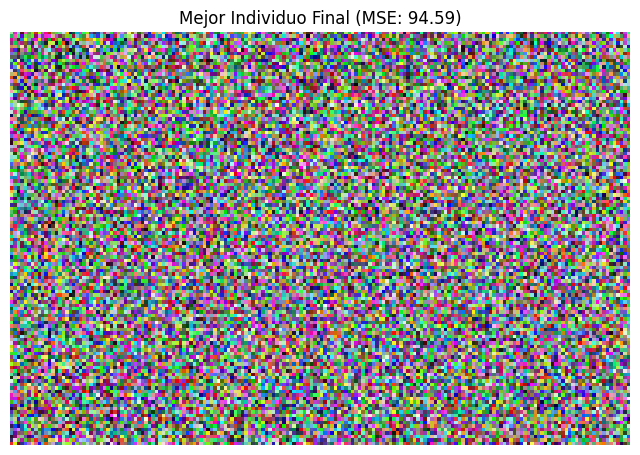

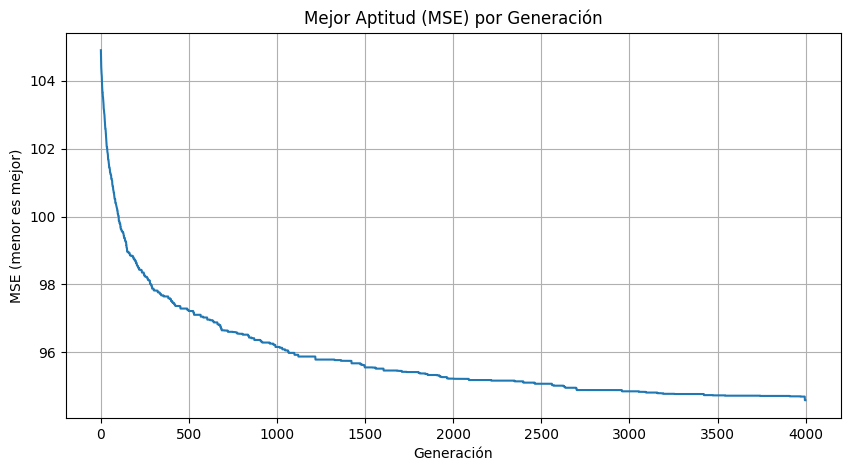

In [33]:
# Mostrar la mejor imagen encontrada
plt.figure(figsize=(8, 6))
plt.imshow(best_individual_per_generation[-1])
plt.title(f'Mejor Individuo Final (MSE: {best_fitness_per_generation[-1]:.2f})')
plt.axis('off')
plt.show()

# Graficar la aptitud a lo largo de las generaciones
plt.figure(figsize=(10, 5))
plt.plot(range(NUM_GENERATIONS), best_fitness_per_generation)
plt.title('Mejor Aptitud (MSE) por Generación')
plt.xlabel('Generación')
plt.ylabel('MSE (menor es mejor)')
plt.grid(True)
plt.show()